In [1]:
print("My project has started!")

My project has started!


In [2]:
import pandas as pd

df = pd.read_excel("C:\Users\india\Desktop\CustomerPurchaseProject/data/online_retail_II.xlsx", sheet_name="Year 2010-2011")

print("Dataset loaded!")
print("Total rows:", len(df))
print("Total columns:", len(df.columns))
print(df.head())

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 2-3: truncated \UXXXXXXXX escape (3045446048.py, line 3)

In [3]:
import pandas as pd

df = pd.read_excel(r"C:\Users\india\Desktop\CustomerPurchaseProject\data\online_retail_II.xlsx", sheet_name="Year 2010-2011")

print("Dataset loaded!")
print("Total rows:", len(df))
print("Total columns:", len(df.columns))
print(df.head())

Dataset loaded!
Total rows: 541910
Total columns: 8
  Invoice StockCode                          Description  Quantity  \
0  536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1  536365     71053                  WHITE METAL LANTERN         6   
2  536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3  536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4  536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  Price  Customer ID         Country  
0 2010-12-01 08:26:00   2.55      17850.0  United Kingdom  
1 2010-12-01 08:26:00   3.39      17850.0  United Kingdom  
2 2010-12-01 08:26:00   2.75      17850.0  United Kingdom  
3 2010-12-01 08:26:00   3.39      17850.0  United Kingdom  
4 2010-12-01 08:26:00   3.39      17850.0  United Kingdom  


In [4]:
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (541910, 8)

Column names:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

First 5 rows:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
print("=== BEFORE CLEANING ===")
print("Total rows:", len(df))
print("Missing values:\n", df.isnull().sum())

=== BEFORE CLEANING ===
Total rows: 541910
Missing values:
 Invoice             0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
Price               0
Customer ID    135080
Country             0
dtype: int64


In [6]:
print("=== CLEANING DATA ===")

# Step 1: Remove rows with missing Customer ID and Description
df_clean = df.dropna(subset=['Customer ID', 'Description'])
print("After removing missing values:", len(df_clean), "rows")

# Step 2: Remove duplicate rows
df_clean = df_clean.drop_duplicates()
print("After removing duplicates:", len(df_clean), "rows")

# Step 3: Remove cancelled orders (Invoice starting with 'C')
df_clean = df_clean[~df_clean['Invoice'].astype(str).str.startswith('C')]
print("After removing cancellations:", len(df_clean), "rows")

# Step 4: Remove negative or zero quantity and price
df_clean = df_clean[df_clean['Quantity'] > 0]
df_clean = df_clean[df_clean['Price'] > 0]
print("After removing bad quantity/price:", len(df_clean), "rows")

print("\n=== CLEANING COMPLETE ===")
print("Original rows:", len(df))
print("Clean rows:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))

=== CLEANING DATA ===
After removing missing values: 406830 rows
After removing duplicates: 401605 rows
After removing cancellations: 392733 rows
After removing bad quantity/price: 392693 rows

=== CLEANING COMPLETE ===
Original rows: 541910
Clean rows: 392693
Rows removed: 149217


In [7]:
# Create TotalAmount column (Quantity x Price)
df_clean = df_clean.copy()
df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['Price']

# Extract Month and Day from InvoiceDate
df_clean['Month'] = df_clean['InvoiceDate'].dt.month
df_clean['DayOfWeek'] = df_clean['InvoiceDate'].dt.day_name()
df_clean['Hour'] = df_clean['InvoiceDate'].dt.hour

print("New columns added successfully!")
print("\nQuick summary:")
print(df_clean[['Quantity', 'Price', 'TotalAmount']].describe().round(2))

New columns added successfully!

Quick summary:
        Quantity      Price  TotalAmount
count  392693.00  392693.00    392693.00
mean       13.12       3.13        22.63
std       180.49      22.24       311.10
min         1.00       0.00         0.00
25%         2.00       1.25         4.95
50%         6.00       1.95        12.45
75%        12.00       3.75        19.80
max     80995.00    8142.75    168469.60


In [8]:
print("=== DESCRIPTIVE STATISTICS ===")

print("\n1. Total revenue:")
print("£", round(df_clean['TotalAmount'].sum(), 2))

print("\n2. Total number of orders:")
print(df_clean['Invoice'].nunique())

print("\n3. Total number of customers:")
print(df_clean['Customer ID'].nunique())

print("\n4. Total number of products:")
print(df_clean['StockCode'].nunique())

print("\n5. Top 5 countries by number of orders:")
print(df_clean['Country'].value_counts().head())

print("\n6. Average order value per invoice:")
order_totals = df_clean.groupby('Invoice')['TotalAmount'].sum()
print("£", round(order_totals.mean(), 2))

=== DESCRIPTIVE STATISTICS ===

1. Total revenue:
£ 8887226.89

2. Total number of orders:
18532

3. Total number of customers:
4338

4. Total number of products:
3665

5. Top 5 countries by number of orders:
Country
United Kingdom    349203
Germany             9025
France              8327
EIRE                7226
Spain               2479
Name: count, dtype: int64

6. Average order value per invoice:
£ 479.56


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\india\\Desktop\\CustomerPurchaseProject\\visuals\\chart1_top_products.png'

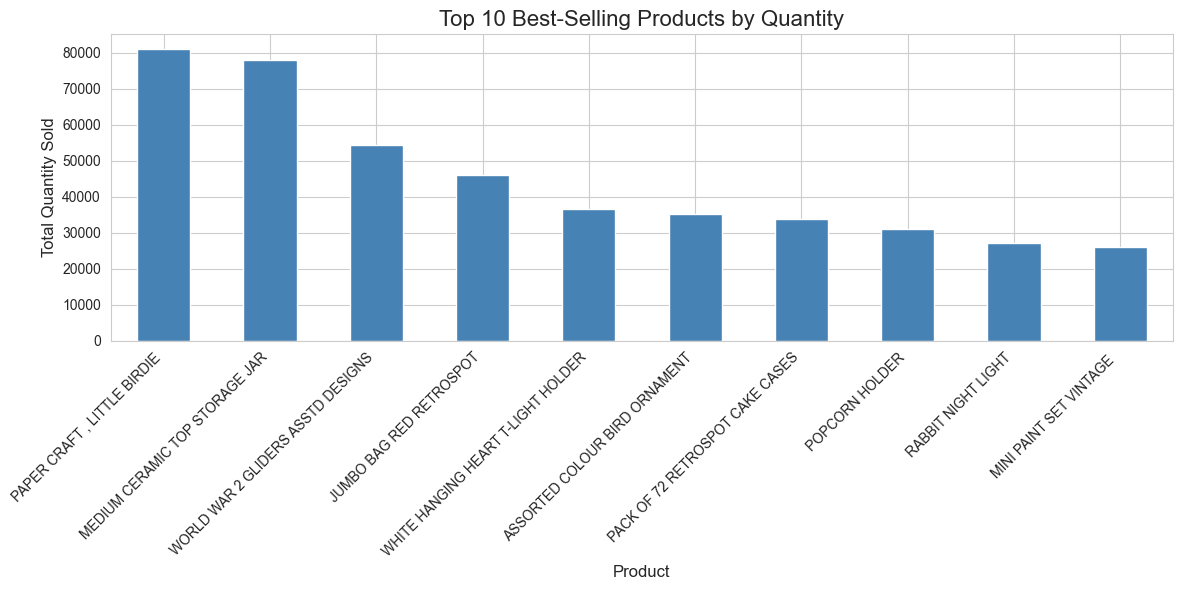

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for all charts
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# ---- CHART 1: Top 10 Best-Selling Products ----
top_products = df_clean.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
top_products.plot(kind='bar', color='steelblue')
plt.title('Top 10 Best-Selling Products by Quantity', fontsize=16)
plt.xlabel('Product', fontsize=12)
plt.ylabel('Total Quantity Sold', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(r"C:\Users\india\Desktop\CustomerPurchaseProject\visuals\chart1_top_products.png", dpi=150)
plt.show()
print("Chart 1 saved!")

In [10]:
import os

# Create all project folders
os.makedirs(r"C:\Users\india\Desktop\CustomerPurchaseProject\visuals", exist_ok=True)
os.makedirs(r"C:\Users\india\Desktop\CustomerPurchaseProject\data", exist_ok=True)
os.makedirs(r"C:\Users\india\Desktop\CustomerPurchaseProject\report", exist_ok=True)
os.makedirs(r"C:\Users\india\Desktop\CustomerPurchaseProject\presentation", exist_ok=True)

print("All folders created!")

All folders created!


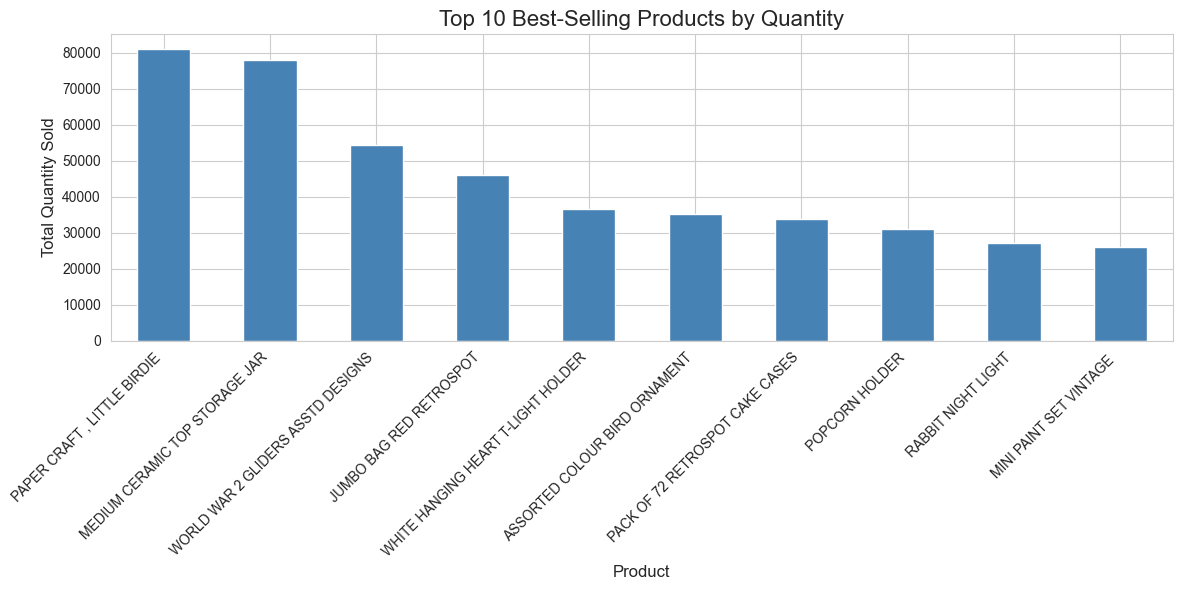

Chart 1 saved!


In [11]:
# ---- CHART 1: Top 10 Best-Selling Products ----
top_products = df_clean.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
top_products.plot(kind='bar', color='steelblue')
plt.title('Top 10 Best-Selling Products by Quantity', fontsize=16)
plt.xlabel('Product', fontsize=12)
plt.ylabel('Total Quantity Sold', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(r"C:\Users\india\Desktop\CustomerPurchaseProject\visuals\chart1_top_products.png", dpi=150)
plt.show()
print("Chart 1 saved!")

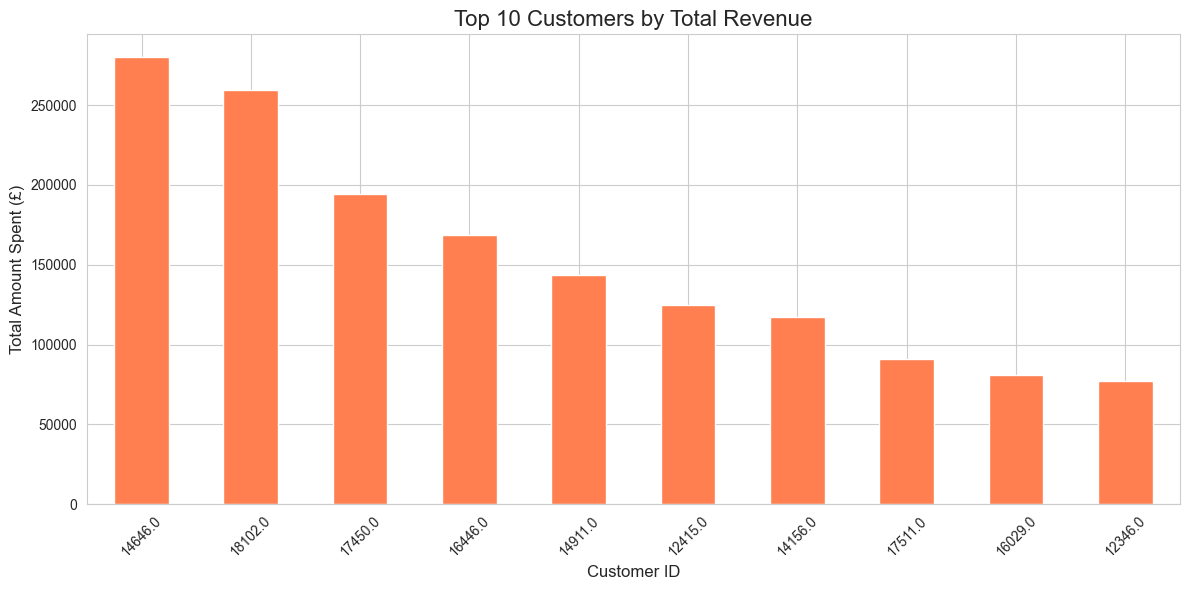

Chart 2 saved!


In [12]:
# ---- CHART 2: Top 10 Customers by Revenue ----
top_customers = df_clean.groupby('Customer ID')['TotalAmount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
top_customers.plot(kind='bar', color='coral')
plt.title('Top 10 Customers by Total Revenue', fontsize=16)
plt.xlabel('Customer ID', fontsize=12)
plt.ylabel('Total Amount Spent (£)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(r"C:\Users\india\Desktop\CustomerPurchaseProject\visuals\chart2_top_customers.png", dpi=150)
plt.show()
print("Chart 2 saved!")

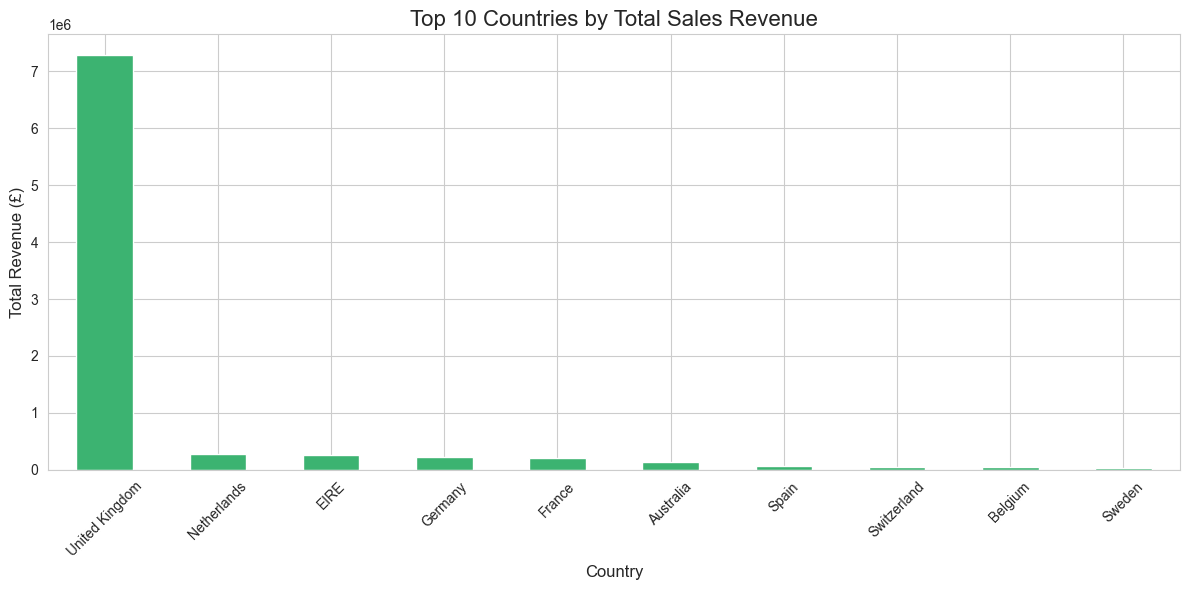

Chart 3 saved!


In [13]:
# ---- CHART 3: Sales by Country (Top 10) ----
top_countries = df_clean.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
top_countries.plot(kind='bar', color='mediumseagreen')
plt.title('Top 10 Countries by Total Sales Revenue', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Total Revenue (£)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(r"C:\Users\india\Desktop\CustomerPurchaseProject\visuals\chart3_sales_by_country.png", dpi=150)
plt.show()
print("Chart 3 saved!")

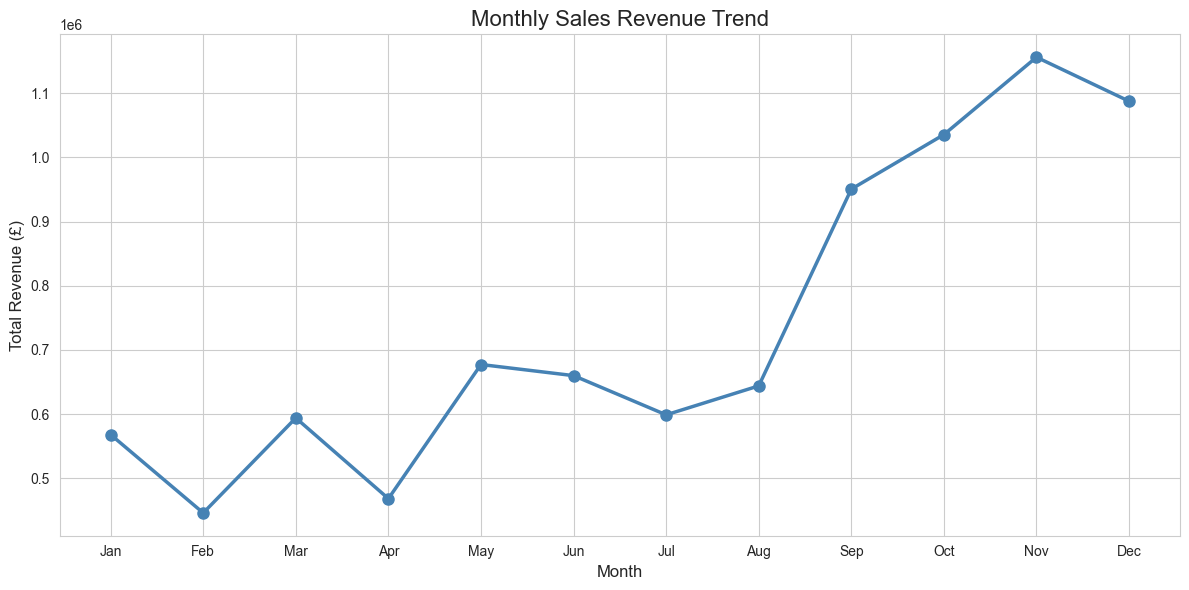

Chart 4 saved!


In [14]:
# ---- CHART 4: Monthly Sales Trend ----
monthly_sales = df_clean.groupby('Month')['TotalAmount'].sum()

plt.figure(figsize=(12, 6))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', color='steelblue', linewidth=2.5, markersize=8)
plt.title('Monthly Sales Revenue Trend', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Revenue (£)', fontsize=12)
plt.xticks(monthly_sales.index, ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.tight_layout()
plt.savefig(r"C:\Users\india\Desktop\CustomerPurchaseProject\visuals\chart4_monthly_sales.png", dpi=150)
plt.show()
print("Chart 4 saved!")

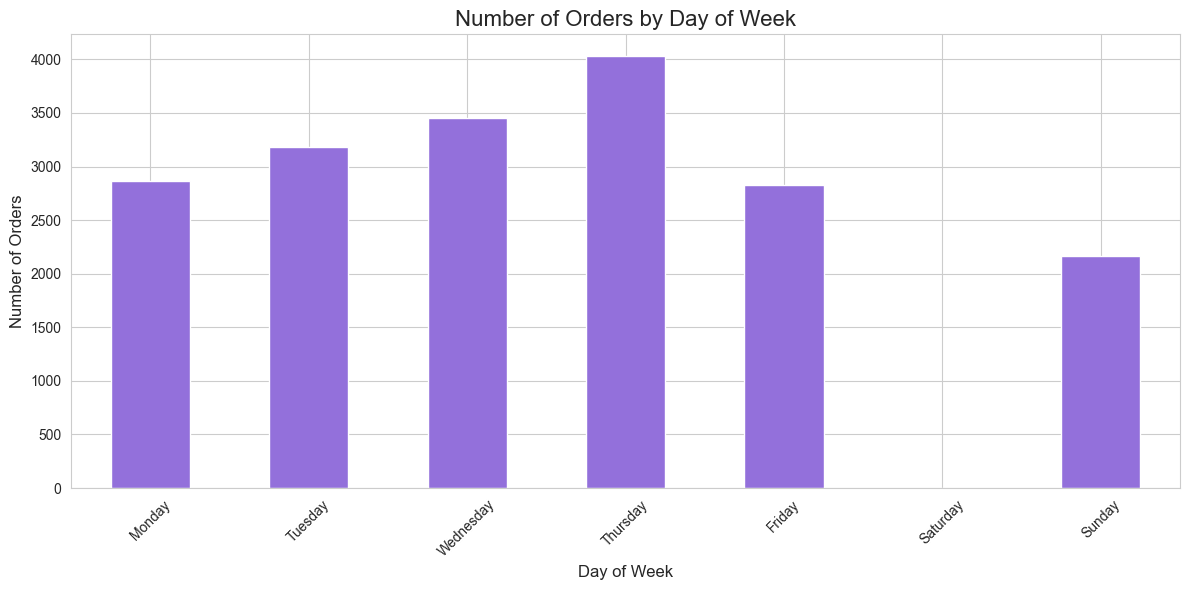

Chart 5 saved!


In [15]:
# ---- CHART 5: Orders by Day of Week ----
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
orders_by_day = df_clean.groupby('DayOfWeek')['Invoice'].nunique().reindex(day_order)

plt.figure(figsize=(12, 6))
orders_by_day.plot(kind='bar', color='mediumpurple')
plt.title('Number of Orders by Day of Week', fontsize=16)
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(r"C:\Users\india\Desktop\CustomerPurchaseProject\visuals\chart5_orders_by_day.png", dpi=150)
plt.show()
print("Chart 5 saved!")

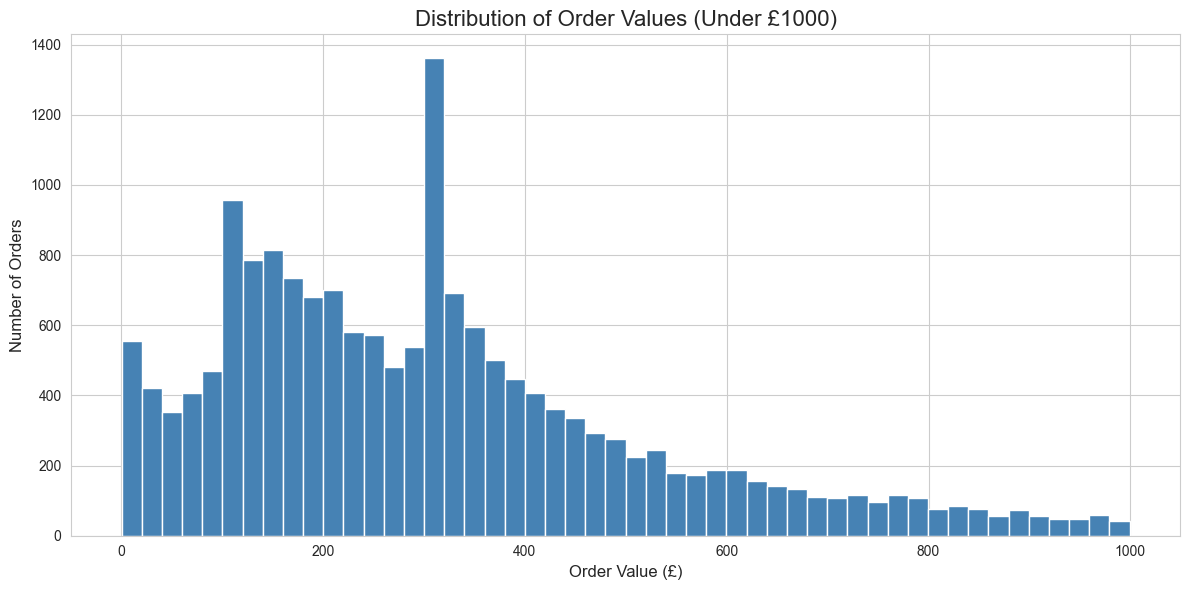

Chart 6 saved!


In [16]:
# ---- CHART 6: Distribution of Order Values (Histogram) ----
order_totals = df_clean.groupby('Invoice')['TotalAmount'].sum()

plt.figure(figsize=(12, 6))
plt.hist(order_totals[order_totals < 1000], bins=50, color='steelblue', edgecolor='white')
plt.title('Distribution of Order Values (Under £1000)', fontsize=16)
plt.xlabel('Order Value (£)', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.tight_layout()
plt.savefig(r"C:\Users\india\Desktop\CustomerPurchaseProject\visuals\chart6_order_distribution.png", dpi=150)
plt.show()
print("Chart 6 saved!")

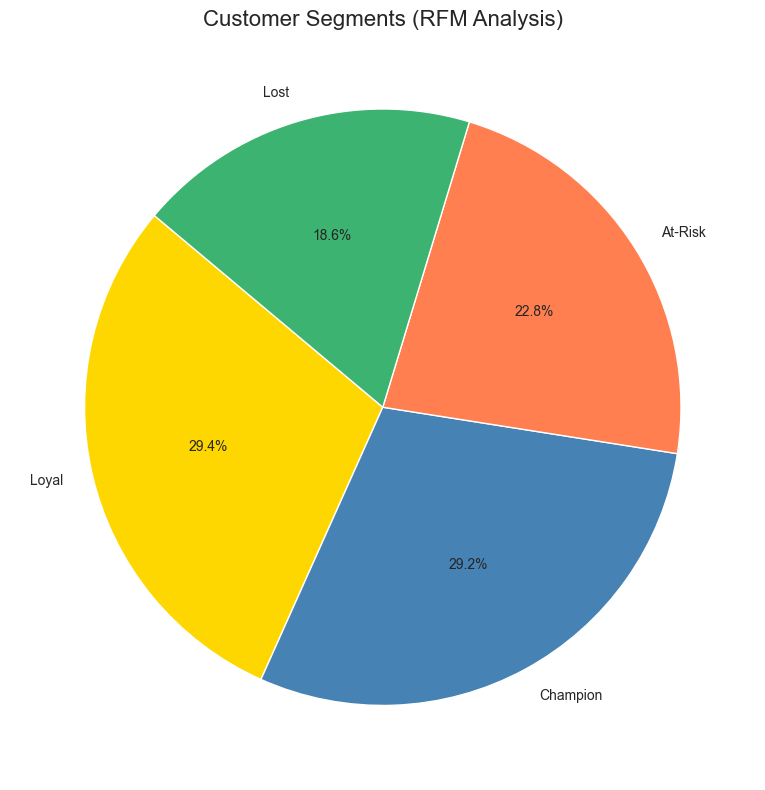

Chart 7 saved!

Segment breakdown:
Segment
Loyal       1276
Champion    1267
At-Risk      989
Lost         806
Name: count, dtype: int64


In [17]:
# ---- CHART 7: RFM Customer Segments ----

# Calculate RFM values
import datetime

reference_date = df_clean['InvoiceDate'].max() + datetime.timedelta(days=1)

rfm = df_clean.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'Invoice': 'nunique',
    'TotalAmount': 'sum'
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

# Score each customer 1-4
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=4, labels=[4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1,2,3,4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=4, labels=[1,2,3,4])

rfm['RFM_Total'] = rfm['R_Score'].astype(int) + rfm['F_Score'].astype(int) + rfm['M_Score'].astype(int)

# Assign segments
def assign_segment(score):
    if score >= 10:
        return 'Champion'
    elif score >= 7:
        return 'Loyal'
    elif score >= 5:
        return 'At-Risk'
    else:
        return 'Lost'

rfm['Segment'] = rfm['RFM_Total'].apply(assign_segment)

# Plot pie chart
segment_counts = rfm['Segment'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(segment_counts.values, labels=segment_counts.index,
        autopct='%1.1f%%', colors=['gold','steelblue','coral','mediumseagreen'],
        startangle=140)
plt.title('Customer Segments (RFM Analysis)', fontsize=16)
plt.tight_layout()
plt.savefig(r"C:\Users\india\Desktop\CustomerPurchaseProject\visuals\chart7_rfm_segments.png", dpi=150)
plt.show()

print("Chart 7 saved!")
print("\nSegment breakdown:")
print(segment_counts)

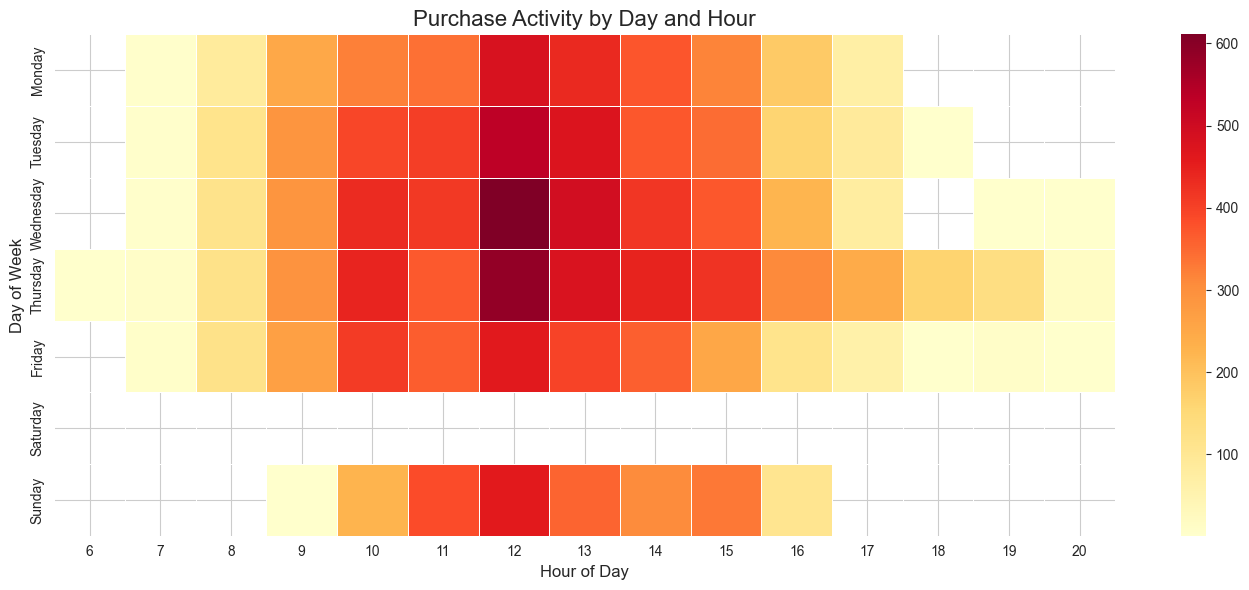

Chart 8 saved!


In [18]:
# ---- CHART 8: Purchases Heatmap by Hour and Day ----
heatmap_data = df_clean.groupby(['DayOfWeek', 'Hour'])['Invoice'].nunique().unstack()
heatmap_data = heatmap_data.reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])

plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_data, cmap='YlOrRd', linewidths=0.5, annot=False)
plt.title('Purchase Activity by Day and Hour', fontsize=16)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Day of Week', fontsize=12)
plt.tight_layout()
plt.savefig(r"C:\Users\india\Desktop\CustomerPurchaseProject\visuals\chart8_heatmap.png", dpi=150)
plt.show()
print("Chart 8 saved!")

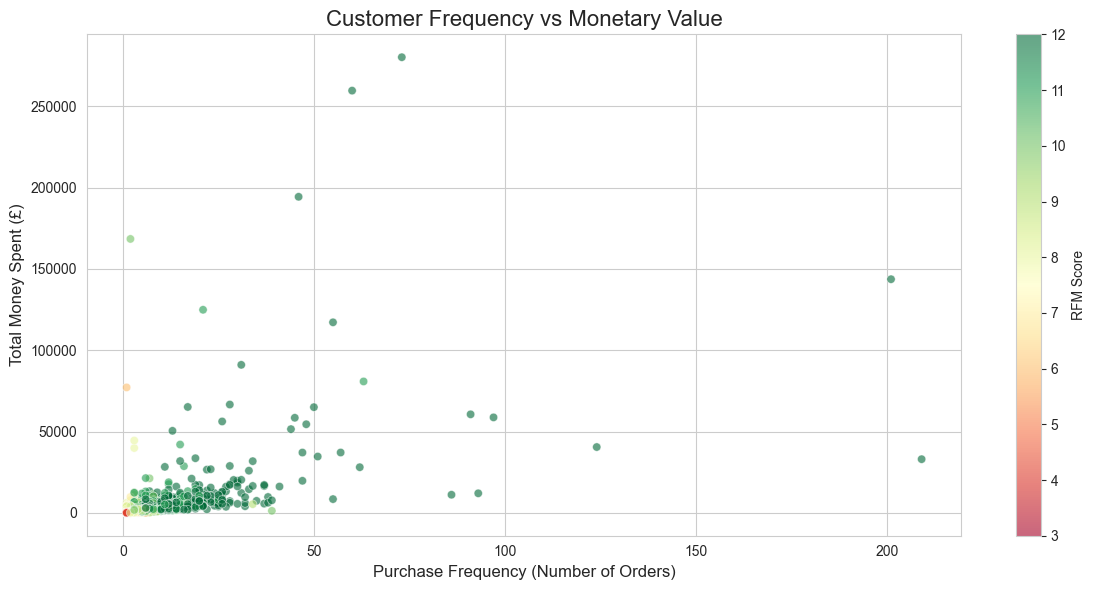

Chart 9 saved!


In [19]:
# ---- CHART 9: Frequency vs Monetary Value (Scatter Plot) ----
plt.figure(figsize=(12, 6))
plt.scatter(rfm['Frequency'], rfm['Monetary'], 
            c=rfm['RFM_Total'], cmap='RdYlGn', 
            alpha=0.6, edgecolors='white', linewidth=0.5)
plt.colorbar(label='RFM Score')
plt.title('Customer Frequency vs Monetary Value', fontsize=16)
plt.xlabel('Purchase Frequency (Number of Orders)', fontsize=12)
plt.ylabel('Total Money Spent (£)', fontsize=12)
plt.tight_layout()
plt.savefig(r"C:\Users\india\Desktop\CustomerPurchaseProject\visuals\chart9_scatter.png", dpi=150)
plt.show()
print("Chart 9 saved!")

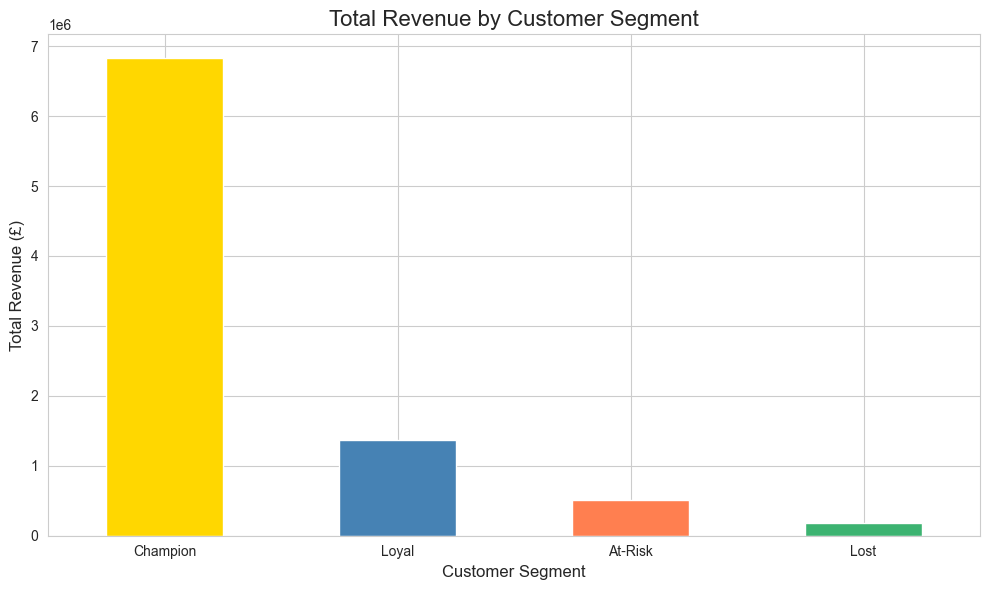

Chart 10 saved!

Revenue by segment:
Segment
Champion    6827253.77
Loyal       1369352.35
At-Risk      512069.51
Lost         178551.26
Name: Monetary, dtype: float64


In [20]:
# ---- CHART 10: RFM Segment Revenue Contribution ----
segment_revenue = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
segment_revenue.plot(kind='bar', color=['gold','steelblue','coral','mediumseagreen'])
plt.title('Total Revenue by Customer Segment', fontsize=16)
plt.xlabel('Customer Segment', fontsize=12)
plt.ylabel('Total Revenue (£)', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(r"C:\Users\india\Desktop\CustomerPurchaseProject\visuals\chart10_segment_revenue.png", dpi=150)
plt.show()
print("Chart 10 saved!")
print("\nRevenue by segment:")
print(segment_revenue.round(2))

In [21]:
import os

visuals_path = r"C:\Users\india\Desktop\CustomerPurchaseProject\visuals"
files = os.listdir(visuals_path)
print(f"Total charts saved: {len(files)}")
for f in sorted(files):
    print("✓", f)

Total charts saved: 10
✓ chart10_segment_revenue.png
✓ chart1_top_products.png
✓ chart2_top_customers.png
✓ chart3_sales_by_country.png
✓ chart4_monthly_sales.png
✓ chart5_orders_by_day.png
✓ chart6_order_distribution.png
✓ chart7_rfm_segments.png
✓ chart8_heatmap.png
✓ chart9_scatter.png
